In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile
import os
from patchify import patchify  #Only to handle large images
import random
from scipy import ndimage
import glob
import cv2
from tqdm import tqdm
import torch

In [2]:
#Used to quickly display an image
def imshow(img, title, cmap = 'gray', axis = 'off', figsize = (10, 10)):
    plt.figure(figsize= figsize)
    plt.imshow(img, cmap = cmap)
    plt.title(title)
    plt.axis(axis)
    plt.show()  

In [3]:
#Storing all file paths of images in a list of strings
import os
directory = r"C:\Users\adamain\Downloads\ProcessedSpiderWebs"
image_paths = []
for filename in os.listdir(directory):
    if filename.lower().endswith(".png"):
        image_paths.append(os.path.join(directory, filename))
print(image_paths)

['C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_19 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_25 - C_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 1_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 2_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 3_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26 - 4_web.png', 'C:\\Users\\adamain\\Downloads\\ProcessedSpiderWebs\\cropped_26

In [4]:
all_images = []
for path in image_paths:
    all_images.append(cv2.imread(path))
    cv2.cvtColor(all_images[len(all_images)-1], cv2.COLOR_BGR2RGB)

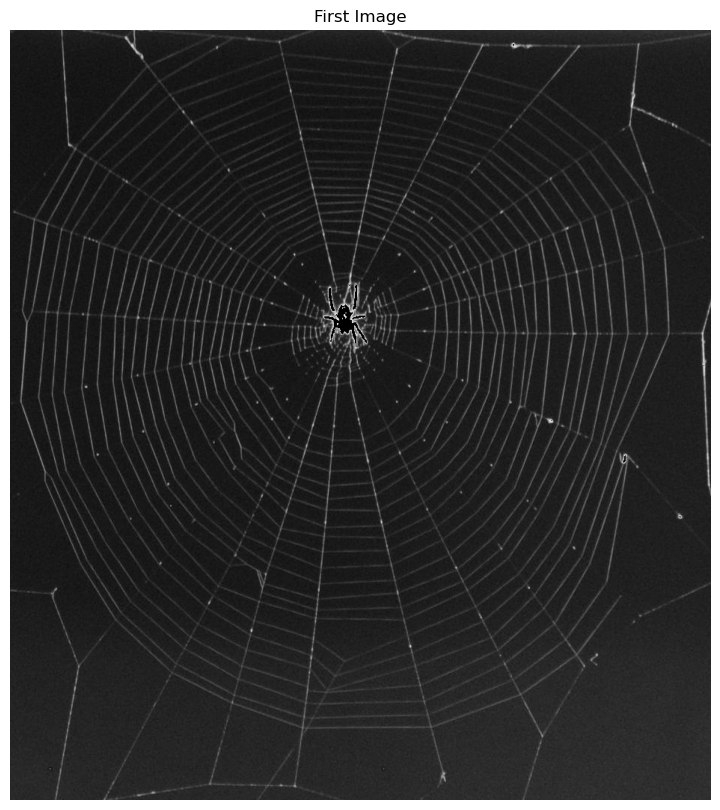

In [5]:
imshow(all_images[0], title = "First Image")

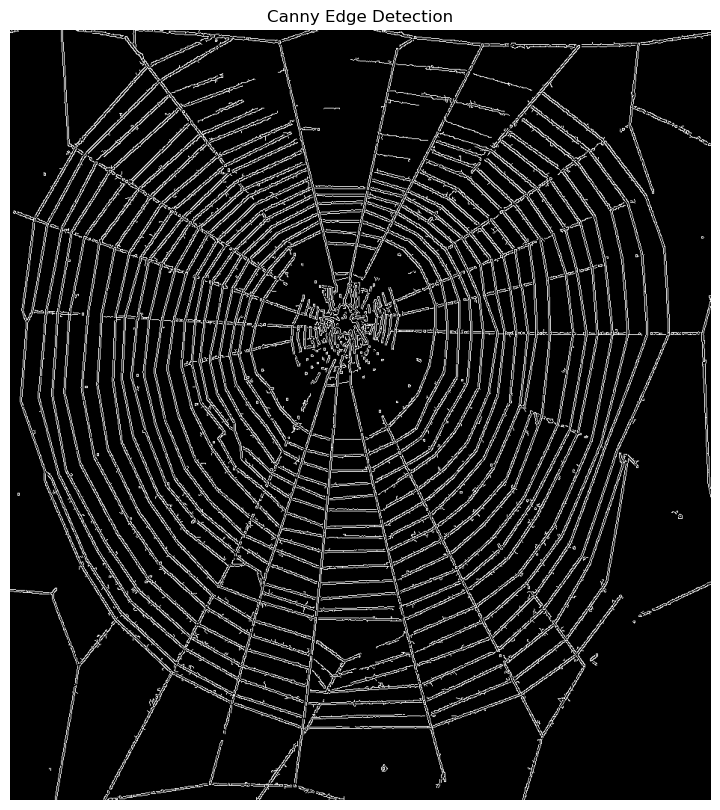

In [6]:
#Preprocessing
gray = cv2.cvtColor(all_images[0], cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 30, 120)
imshow(edges, "Canny Edge Detection")

In [7]:
def endpoint_direction(ep, edge_img):
    y, x = ep
    # Get gradients
    gx = cv2.Sobel(edge_img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(edge_img, cv2.CV_64F, 0, 1, ksize=3)
    dx, dy = gx[y, x], gy[y, x]
    norm = np.hypot(dx, dy) + 1e-8
    return np.array([dx / norm, dy / norm])


In [13]:
import cv2
import numpy as np
from scipy.ndimage import convolve
from scipy.spatial.distance import cdist

def find_endpoints(edge_img):
    kernel = np.array([[1,1,1],
                       [1,0,1],
                       [1,1,1]])
    neighbor_count = convolve(edge_img.astype(np.uint8), kernel, mode='constant', cval=0)
    endpoints = np.argwhere((edge_img > 0) & (neighbor_count <= 2))
    return endpoints



In [14]:
from scipy.spatial.distance import cdist

from sklearn.neighbors import NearestNeighbors

def connect_filtered_endpoints_fast(edges, max_dist=10, max_angle_deg=5):
    endpoints = find_endpoints(edges)
    if len(endpoints) < 2:
        return edges.copy()

    dirs = np.array([endpoint_direction(ep, edges) for ep in endpoints])
    connected = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)

    nbrs = NearestNeighbors(radius=max_dist, algorithm='kd_tree').fit(endpoints)
    pairs = nbrs.radius_neighbors(endpoints, return_distance=False)

    for i, neighbors in enumerate(pairs):
        for j in neighbors:
            if i >= j:
                continue  # avoid duplicates
            angle = np.degrees(np.arccos(np.clip(np.abs(np.dot(dirs[i], dirs[j])), 0, 1)))
            if angle <= max_angle_deg:
                pt1 = tuple(endpoints[i][::-1])
                pt2 = tuple(endpoints[j][::-1])
                cv2.line(connected, pt1, pt2, (0, 255, 0), 1)

    return connected


In [17]:
def plot_endpoints_on_image(edge_img, endpoints, color=(255, 0, 0), radius=3, thickness=-1):
    """
    Draws colored circles at endpoint locations on a color version of the edge image.
    Params:
    - edge_img: binary or grayscale edge image
    - endpoints: Nx2 array of (y, x) coordinates
    - color: BGR tuple for circle color (default blue)
    - radius: circle radius
    - thickness: -1 to fill circle
    
    Returns:
    - img_with_endpoints: color image with endpoints drawn
    """
    # Convert grayscale edge to BGR color image for colored drawing
    if len(edge_img.shape) == 2:
        img_color = cv2.cvtColor(edge_img, cv2.COLOR_GRAY2BGR)
    else:
        img_color = edge_img.copy()

    for (y, x) in endpoints:
        cv2.circle(img_color, (x, y), radius, color, thickness)
    
    return img_color


Found 27 endpoints


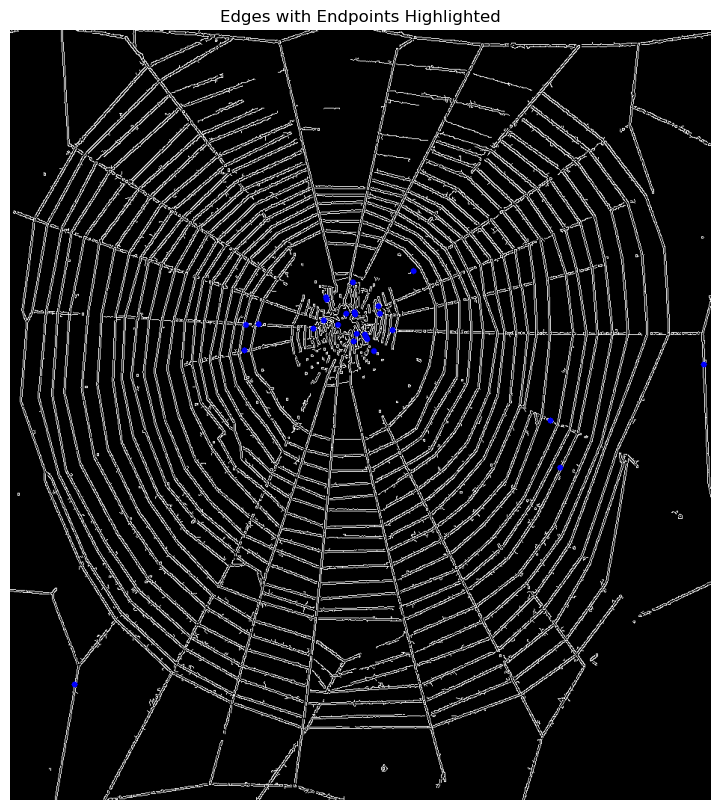

In [ ]:
#Take a look at last chat with gpt about thinning out the webs.
endpoints = find_endpoints(edges)
print(f"Found {len(endpoints)} endpoints")

img_with_points = plot_endpoints_on_image(edges, endpoints, color=(0, 0, 255), radius=4)
imshow(img_with_points, "Edges with Endpoints Highlighted", cmap=None)

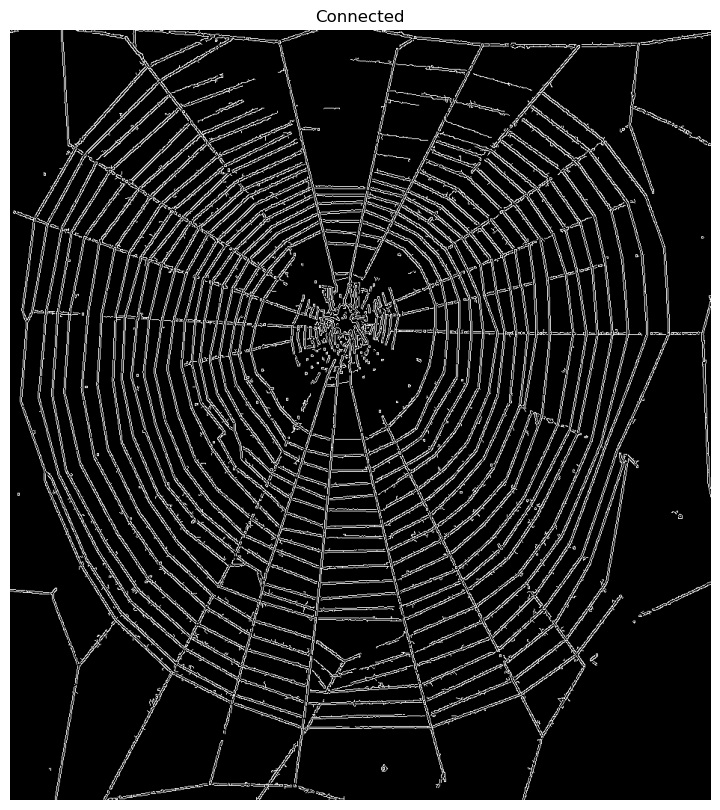

In [16]:
connected = connect_filtered_endpoints_fast(edges, max_dist= 5, max_angle_deg=15)
imshow(connected, title = "Connected")
